In [1]:
import os
import sys

In [2]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [3]:
import pathlib
import math
import numpy as np
import matplotlib.pyplot as plt
import qpc.tools as tools
from qpc.tools import mv
from qpc import evolution
from concurrent.futures import ProcessPoolExecutor

In [4]:
ed_list, J_exact = np.loadtxt('./current_vs_ed.txt', unpack=True)

Text(0, 0.5, 'current')

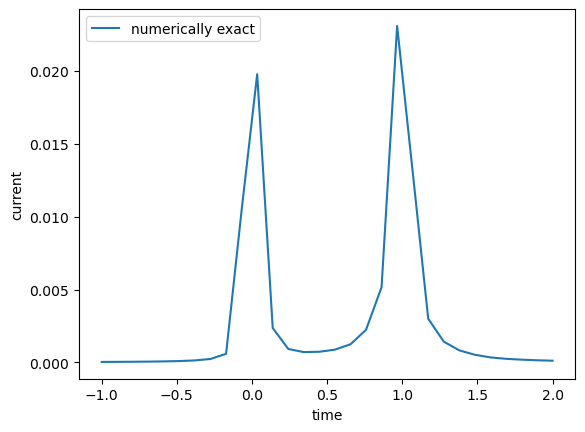

In [5]:
import matplotlib.pyplot as plt
plt.plot(ed_list, J_exact, label = 'numerically exact')
plt.legend()
plt.xlabel('time')
plt.ylabel('current')

In [7]:
e_d = ed_list[19]
e_d

np.float64(0.96551724138)

In [8]:
J_exact[19]

np.float64(0.023078163492)

In [17]:
e = 1     # on-site energy
h = 0.05  # hopping

ns = 200 # number of sites in a single lead

e_ = [e]*ns
h_ = [h]*ns
chain = np.column_stack((e_, h_))
chain[0,1] = h # coupling to QPC

In [18]:
# save chain parameters
np.savetxt('./chain.txt', chain, delimiter=' ')

In [13]:
dt = 0.01

In [19]:
# find the light cone
!qpc-prepare.py --tmax=800 --rtol=1E-5 --dt=0.01 --ringmax=5 --fout=lc

Wellcome to lightcone constructor version 01.03.2023-14.44
Semiinfinite chain file:  chain.txt
Length of chain:  200
Relative significance treshold for forward lightcone boundary:  1e-05
Maximal size of ring:  5
Maximal time:  800.0
Time step:  0.01
Coupling to impurity:  0.05
The execution time : 28.512447357177734  sec


In [ ]:
# now run the quantum jump simulation on longer time range
!qpc-solve.py --maxcores=1 --cfrom=1 --cto=1 --csize=1 --U=1 --e_d=0.965 --fin=lc --fout=result_0.965 --nquanta=7 --tmax=800

Wellcome to lightcone impurity solver version 10.03.2023-11.51
Will read the lightcone info from the current directory
Will compute  1  trajectories
on max  1  CPU cores
Will save results into  result_0.55
Will load lightcones from  /home/evgenii/condmat/qpc/QPC-5_coulomb_in_solver/qpc/notebooks/lc
Will simulate up to time 800.0
Max number of coupled quanta:  7
on-site energy:  1
hopping:  0.05
Gate voltage e_d:  0.965
Coulomb interaction U:  1
Max number of coupled modes:  5
computing sparse matrices...
...done
submitting jobs to pool ...
running chunk  1 , of  1  trajectories
chunk  1  execution time:  230.0996606349945  sec
finished  1 job  out of  1

Done!


In [ ]:
# read results

import sys
import numpy as np
import os
import pathlib

folder = "result_0.0.965"

with pathlib.Path(os.path.join(os.getcwd(), folder, "time.txt")).open() as f:
    tg = np.loadtxt(f)

ntg = tg.size
    
x = np.zeros(ntg, dtype = complex)
    
p = os.path.join(os.getcwd(), folder, "x_" + str(1) + ".txt")
p = pathlib.Path(p)
    
with p.open() as f:
    xc = np.loadtxt(f)    
    x[0 : xc.shape[0] - 1] += xc[1:, 0] + 1j * xc[1:, 1]    

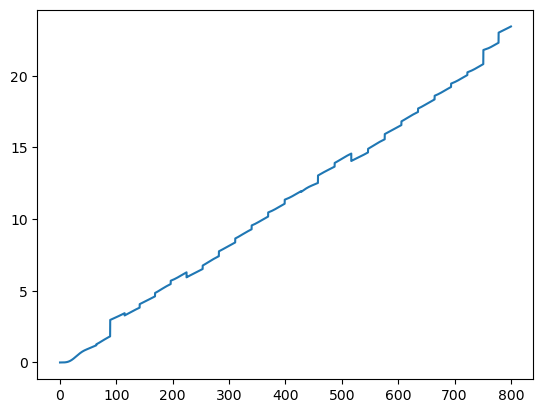

In [14]:
plt.plot(tg, x.real, label = 'jumps')

In [15]:
J_lc = (x[799*100] - x[100 * 100]) / (699 * 100 * dt)

In [16]:
J_lc

np.complex128(0.028985210144111404+0j)